This file follows the example in section 5.25 of the second edition of "A First Course Computational Physics" by Paul L. DeVries and Javier E. Hasbun. The example also appears in the first edition.

Consider the following second order homogeneous ordinary differential equation

$$
y^{\prime\prime} - 6x = 0
$$

subject to the boundary conditions $y(0) = 0\,, y(1) = 1\,.$

Define the following basis functions:

$$
\phi_i(x) = 
\begin{cases}
0\,, &x \le x_{i-1}\, &\\[2mm]
\dfrac{x - x_{i-1}}{x_i - x_{i-1}}\,, &x_{i-1} \le x \le x_i\, &&\\[2mm]
\dfrac{x_{i+1} - x}{x_{i+1} - x_{i}}\,, &x_{i} \le x \le x_{i+1}\, &&\\[2mm]
0\,, & x_{i+1} \le x\,.
\end{cases}
$$

Define an arbitrary piecewise linear trial function $p(x)$ which can be written as

$$
p(x) = \sum_{i=0}^{N}c_{i}\phi_i(x)\,.
$$

where the total region has been broken into $N$ intervals where $p(0) = y(0)$ and $p(1)= y(1)\,.$ Unpacking this we get 

$$
p(x) = c_0\phi_0(x) + c_1\phi_1(x) +\,\ldots\,+c_N\phi_{N}(x)\,.
$$

The boundary conditions mean that $p(0) = c_0\phi_0(0) = 0$ and that $p(1) = c_{N}\phi_{N}(x) = y(1)\,.$
Since $\phi_0(0)=1$ and $\phi_{N}(1)=1$ it follows that $c_0 = 0$ and that $c_{N} = y(1) = 1\,.$

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate
import time

#%matplotlib ipympl

In [2]:
N = 10
nodes = np.zeros(N+1)
print("The number of nodes: ",len(nodes))
for i in range(N+1):
    nodes[i] = i*0.1

The number of nodes:  11


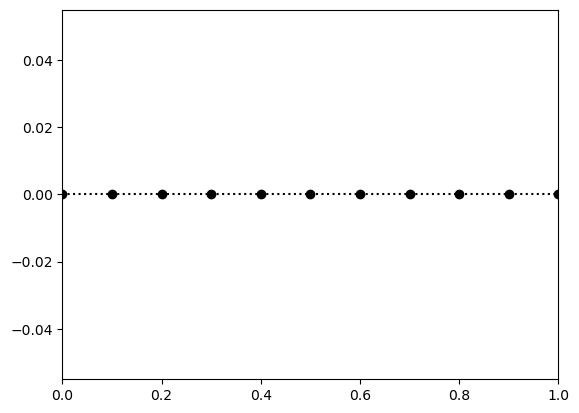

In [3]:
plt.figure(1)
plt.axhline(0.0,ls=':',color ='k')
for i in range(len(nodes)):
    plt.plot(nodes[i],0,  'o', color = 'k')
plt.xlim(0,1)
plt.show()

We now code up up the basis functions. I learned how to do this by consulting the following link

https://songhuiming.github.io/pages/2015/09/22/piecewise-linear-function-and-the-explanation/

In [4]:
# N+1 basis functions

def phi0(x):
    condlist = [(x<=-0.1), (x>=-0.1) & (x<=nodes[0]), (x>=nodes[0]) & (x<=nodes[1]), (x>=nodes[1])]
    funclist = [lambda x: 0, lambda x: (x - (-0.1))/(nodes[0] - (-0.1)), lambda x: (nodes[1]-x)/(nodes[1] - nodes[0]), lambda x: 0]
    return np.piecewise(x, condlist, funclist)
    
def phi1(x):
    condlist = [(x<=nodes[0]), (x>=nodes[0]) & (x<=nodes[1]), (x>=nodes[1]) & (x<=nodes[2]), (x>=nodes[2])]
    funclist = [lambda x: 0, lambda x: (x - nodes[0])/(nodes[1] - nodes[0]), lambda x: (nodes[2]-x)/(nodes[2] - nodes[1]), lambda x: 0]
    return np.piecewise(x, condlist, funclist)

def phi2(x):
    condlist = [(x<=nodes[1]), (x>=nodes[1]) & (x<=nodes[2]), (x>=nodes[2]) & (x<=nodes[3]), (x>=nodes[3])]
    funclist = [lambda x: 0, lambda x: (x - nodes[1])/(nodes[2] - nodes[1]), lambda x: (nodes[3]-x)/(nodes[3] - nodes[2]), lambda x: 0]
    return np.piecewise(x, condlist, funclist)

def phi3(x):
    condlist = [(x<=nodes[2]), (x>=nodes[2]) & (x<=nodes[3]), (x>=nodes[3]) & (x<=nodes[4]), (x>=nodes[4])]
    funclist = [lambda x: 0, lambda x: (x - nodes[2])/(nodes[3] - nodes[2]), lambda x: (nodes[4]-x)/(nodes[4] - nodes[3]), lambda x: 0]
    return np.piecewise(x, condlist, funclist)

def phi4(x):
    condlist = [(x<=nodes[3]), (x>=nodes[3]) & (x<=nodes[4]), (x>=nodes[4]) & (x<=nodes[5]), (x>=nodes[5])]
    funclist = [lambda x: 0, lambda x: (x - nodes[3])/(nodes[4] - nodes[3]), lambda x: (nodes[5]-x)/(nodes[5] - nodes[4]), lambda x: 0]
    return np.piecewise(x, condlist, funclist)

def phi5(x):
    condlist = [(x<=nodes[4]), (x>=nodes[4]) & (x<=nodes[5]), (x>=nodes[5]) & (x<=nodes[6]), (x>=nodes[6])]
    funclist = [lambda x: 0, lambda x: (x - nodes[4])/(nodes[5] - nodes[4]), lambda x: (nodes[6]-x)/(nodes[6] - nodes[5]), lambda x: 0]
    return np.piecewise(x, condlist, funclist)

def phi6(x):
    condlist = [(x<=nodes[5]), (x>=nodes[5]) & (x<=nodes[6]), (x>=nodes[6]) & (x<=nodes[7]), (x>=nodes[7])]
    funclist = [lambda x: 0, lambda x: (x - nodes[5])/(nodes[6] - nodes[5]), lambda x: (nodes[7]-x)/(nodes[7] - nodes[6]), lambda x: 0]
    return np.piecewise(x, condlist, funclist)

def phi7(x):
    condlist = [(x<=nodes[6]), (x>=nodes[6]) & (x<=nodes[7]), (x>=nodes[7]) & (x<=nodes[8]), (x>=nodes[8])]
    funclist = [lambda x: 0, lambda x: (x - nodes[6])/(nodes[7] - nodes[6]), lambda x: (nodes[8]-x)/(nodes[8] - nodes[7]), lambda x: 0]
    return np.piecewise(x, condlist, funclist)

def phi8(x):
    condlist = [(x<=nodes[7]), (x>=nodes[7]) & (x<=nodes[8]), (x>=nodes[8]) & (x<=nodes[9]), (x>=nodes[9])]
    funclist = [lambda x: 0, lambda x: (x - nodes[7])/(nodes[8] - nodes[7]), lambda x: (nodes[9]-x)/(nodes[9] - nodes[8]), lambda x: 0]
    return np.piecewise(x, condlist, funclist)

def phi9(x):
    condlist = [(x<=nodes[8]), (x>=nodes[8]) & (x<=nodes[9]), (x>=nodes[9]) & (x<=nodes[10]), (x>=nodes[10])]
    funclist = [lambda x: 0, lambda x: (x - nodes[8])/(nodes[9] - nodes[8]), lambda x: (nodes[10]-x)/(nodes[10] - nodes[9]), lambda x: 0]
    return np.piecewise(x, condlist, funclist)
                            
def phi10(x):
    condlist = [(x<=nodes[9]), (x>=nodes[9]) & (x<=nodes[10]), (x>=nodes[10]) & (x<=1.1), (x>=1.1)]
    funclist = [lambda x: 0, lambda x: (x - nodes[9])/(nodes[10] - nodes[9]), lambda x: (1.1-x)/(1.1 - nodes[10]), lambda x: 0]
    return np.piecewise(x, condlist, funclist)

    

Let's plot the basis functions. To do so we form a set containing the values of the spatial co-ordinate $x$ over which we wish to plot and a list containing the basis functions.

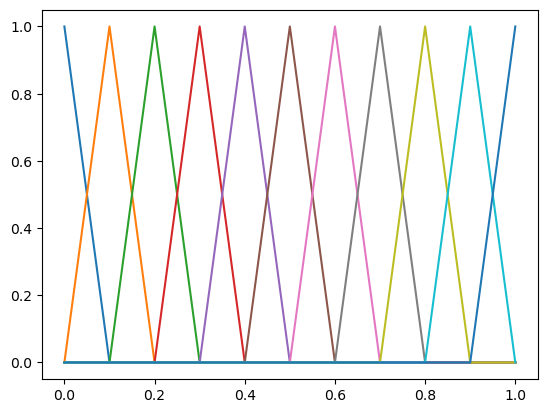

In [5]:
x = np.linspace(0,1,1001)

basis = [phi0(x), phi1(x), phi2(x), phi3(x), phi4(x), phi5(x),\
         phi6(x), phi7(x), phi8(x), phi9(x), phi10(x)]

plt.figure(2)
for i in range(N+1):
    plt.plot(x,basis[i])
plt.show()

We now define the separation between each node by $h$. We can do this in this example because we've chosen the nodes to be uniformly distributed. Since the nodes a re uniformly distributed $h = 1/N\,,$ where $N$ is the number of elements.

In [6]:
h = 1/N

The function $p(x)$ is the approximating function and we code this up as

In [7]:
def p(x):
    return sum(c[i]*basis[i] for i in range(N+1))

To find the values of the coefficients $c_i$ we must solve the following matrix problem

$$
\begin{pmatrix} 
-2 & 1 & 0 &  &  & \\ 
1 & -2 & 1 & \\
 &  & \ddots \\
 &  &  & 1 & -2 & 1\\
 &  &  & 0 & 1 & -2
\end{pmatrix}
\begin{pmatrix} 
c_1 \\ 
c_2 \\
\vdots  \\
c_{N-2}\\
c_{N-1}
\end{pmatrix}
$$


$$
=\begin{pmatrix}6h^2x_1 - c_0 \\ 6h^2x_2 \\ \vdots \\ 6h^2x_{N-2} \\ 6h^2x_{N-1} - c_{N}
\end{pmatrix}\,.
$$

We can write this as ${\mathbb K}{\bf c} = {\bf b}\,.$

Denoting the connectivity matrix, ${\mathbb K}\,,$ we have

In [8]:
K = np.zeros((N-1,N-1)) 

In [9]:
np.fill_diagonal(K, -2.0)

for i in range(1,N-1):
    K[i-1,i] = 1.0
    K[i,i-1] = 1.0

In [10]:
K

array([[-2.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 1., -2.,  1.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  1., -2.,  1.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  1., -2.,  1.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  1., -2.,  1.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  1., -2.,  1.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  1., -2.,  1.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  1., -2.,  1.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  1., -2.]])

In [11]:
K.shape

(9, 9)

Defining by ${\bf b}$ the column vector

$$
{\bf b} = \begin{pmatrix}6h^2x_1 - c_0 \\ 6h^2x_2 \\ \vdots \\ 6h^2x_{N-2} \\ 6h^2x_{N-1} - c_{N}
\end{pmatrix}\,,
$$

$c_0 = 0$ and $c_N = 1$ we code this as

In [12]:
b = np.zeros(N-1)
b.shape

(9,)

In [13]:
c0 = 0
cN = 1

b[0] = 6.*h**2*nodes[1] - c0
b[-1] = 6.*h**2*nodes[-2] - cN

for i in range(1,N-2):
    b[i] = 6.*h**2*nodes[i+1]
    
print(b)

[ 0.006  0.012  0.018  0.024  0.03   0.036  0.042  0.048 -0.946]


In [14]:
start_time = time.time()
c_sub = np.linalg.solve(K,b)
end_time = time.time()
execution_time = end_time - start_time
print(execution_time)

0.004765987396240234


In [15]:
c_sub

array([0.001, 0.008, 0.027, 0.064, 0.125, 0.216, 0.343, 0.512, 0.729])

In [16]:
c = np.zeros(N+1)

In [17]:
c[-1] = 1.0
for i in range(1,N):
    c[i] = c_sub[i-1]

print(c)

[0.00e+00 1.00e-03 8.00e-03 2.70e-02 6.40e-02 1.25e-01 2.16e-01 3.43e-01
 5.12e-01 7.29e-01 1.00e+00]


We now plot the numerical solution, $p(x)$, the coefficients, $c_i$, and the exact solution

$y(x) = x^3\,.$

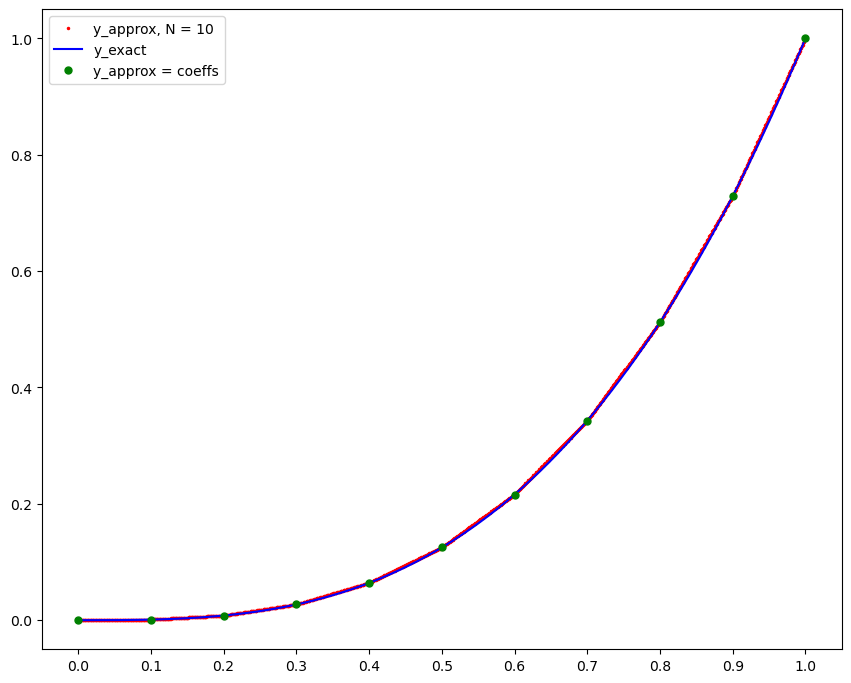

In [18]:
fig4 = plt.figure(4,figsize=(10,8))
ax = fig4.add_axes([0.1, 0.1, 0.8, 0.8])
plt.plot(x,p(x), '.', markersize = 3.0, color = 'r',label=r'y_approx, N = 10')
plt.plot(x, x**3, color = 'b', label = r'y_exact')
plt.plot(nodes[0], c[0], 'o', markersize=5, color = 'g', label = r'y_approx = coeffs')
for i in range(1,N+1):
    plt.plot(nodes[i], c[i], 'o', markersize=5, color = 'g')
ax.set_xticks([0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0])
ax.set_xticklabels(['0.0','0.1','0.2','0.3','0.4','0.5','0.6','0.7','0.8','0.9','1.0'])
plt.legend()
plt.show()